# Quantum Support Vector Machines (QSVM)

> **Quantum Support Vector Machines** is the quantum version of classical Support Vector Machines (SVM); i.e., a data classification method that separates the data by performing a mapping to a high-dimensional space, in which the data is separated by a hyperplane [[1](#learning)]. QSVM is a hybrid quantum–classical classification algorithm in which classical data are embedded into a high-dimensional quantum Hilbert space using a parameterized quantum feature map. A quantum processor is then used to evaluate inner products between these quantum states, producing a kernel matrix that captures similarities between data points in this quantum feature space. This kernel is passed to a classical support vector machine optimizer, which learns the optimal separating hyperplane by identifying support vectors and model parameters. For prediction, the trained model classifies new data points using quantum-evaluated kernel values and a classical decision rule. For some problem instances, a quantum feature map may enable improved classification performance while using fewer computational resources than a classical algorithm [[2](#speedup)].    
>
> The algorithm treats the following problem:
>
> - **Input:** Classical data points ${\mathbf{x}_i}$, where $\mathbf{x}_i\in \mathbb{R}^d$ are d-dimensional vectors, corresponding labels $y_i \in\{-1, 1\}$, where $i=1,\dots,m$, as well as feature map $U_\phi(\mathbf{x}_i)$, encoding the classical data in a quantum state.
> - **Output:** A kernel matrix evaluated using quantum measurements. The matrix is then fed into a classical SVM optimizer, producing a full characterization of the separating hyperplane.
> 
> ---
>
> **Keywords:**  Quantum Machine Learning (QML), hybrid quantum–classical algorithm, supervised learning, binary classification. 

## Background

Our goal is to find a hyperplane in $\mathbb{R}^d$ which separates the points $\{\mathbf{x}_i\}$ into ones for which the corresponding labels are $y_i = +1$ and $y_i = -1$. The hyperplane is conveniently defined by a vector normal to it, $\mathbf{w} \in \mathbb{R}^d$ and an offset $b \in \mathbb{R}$. The classification of a point $\mathbf{x}$ can be determined by $h_{\mathbf{w}}(\mathbf{x}) = \text{sign}(\langle \mathbf{w},\mathbf{x} \rangle + b)$, which decides on which side of the hyperplane the point lies on. Here $\langle \mathbf{w},\mathbf{x} \rangle$ is the inner product between the two vectors.

To describe the goal explicitly, we introduce the **geometric margin** as the distance from the hyperplane to the closest training point $\mathbf{x}_i$: $\min_{\mathbf{x}}((\langle \mathbf{w},\mathbf{x} \rangle/||\mathbf{w}||)$. The optimal classification corresponds to the hyperplane and offset that maximizes the geometric margin.
This goal can be stated as a naive optimization problem: find $\mathbf{w}$ satisfying 



$$\text{max}_{\mathbf{w}}\text{min}_{\mathbf{i}}(\text{sign} (\langle \mathbf{w},\mathbf{x}_i \rangle + b ))$$


$$\text{subject to: }~~\text{sign}(\langle \mathbf{w},\mathbf{x}_i \rangle + b) = \text{sign}(y_i)~. $$

However, this formulation of the problem is a nonlinear optimization problem due to the sign comparison. Alternatively, we can express the objective as a linear function with linear constraints. A separating hyperplane satisfies
$(\langle \mathbf{w},\mathbf{x}_i \rangle + b)y_i \geq 0 ~~, $ moreover, we set the length of $\mathbf{w}$ by enforcing that the inner product with respect to the nearest point (in fact, there will always be two data points on each side of the hyperplane with the same minimal distance to the hyperplane) to be $\langle \mathbf{w},\mathbf{x}_{\min} \rangle = 1$. As a result, all data points satisfy $(\langle \mathbf{w},\mathbf{x}_i \rangle + b)y_i \geq 1$.  The condition enables defining the optimization problem

$${\text{minimize}~ \frac{1}{2}} || \mathbf{w}||^2 $$

$$\text{subject to }~~ (\langle \mathbf{w},\mathbf{x}_i \rangle + b)y_i \geq 1~~~~\text{for}~~~~i=1,\dots,m~.$$

In general, it would not be possible to separate the bare data points by a hyperplane; therefore, a transformation of the data to a higher-dimensional space using a feature map $\phi(\mathbf{x})$ is performed. Following the transformation, the hyperplane and offset are evaluated (similar problem, obtained by transforming $\mathbf{x}_i \rightarrow \phi(\mathbf{x}_i)$). The main disadvantage of the present (primal) formulation of the problem is that explicitly computing $\phi(\mathbf{x})$ may require infeasible computational resources, or even involve a mapping to an infinite-dimensional space.

An alternative approach utilizes the dual formulation of the problem. This approach relies on the **Karush-Kuhn-Tucker theorem** [[3](#KKT)], which implies that one can formulate a dual optimization problem, whose solution (under certain conditions which are satisfied for the present case) coincides with the solution of the present (primal) problem. The dual problem of the original primal optimization problem is given by 
$$\text{maximize}~~ {\cal{L}}_D(\alpha_1,\dots,\alpha_m) = \sum_{i=1}^m \alpha_i - \frac{1}{2} \sum_{i,j=1}^m y_i y_j \alpha_i \alpha_j K(\mathbf{x}_i, \mathbf{x}_j) \tag{2}  $$
$$\text{subject to:}~~~~\alpha_i \geq 0~~~~\text{for}~~~~i=1,\dots,m~~$$
$$\sum_{i=1}^m y_i \alpha_i = 0~~,$$
where $K(\mathbf{x}_i, \mathbf{x}_j) = \langle \mathbf{x}_i,\mathbf{x}_j \rangle$ is the $(i,j)$  component of the matrix, called the kernel matrix. 
The important advantage of the dual formulation is that for specific feature maps, evaluation of the kernel matrix components does not require explicit assessment of the inner product of two feature vectors (which might be infinite-dimensional after the feature map transformation).


The quantum version of SVM is based on the dual optimization problem, where the main innovation is that a quantum computer can perform unitary feature transformations by applying quantum circuits and evaluate the inner product between transformed states by specified measurements. 

## QSVM Algorithms

The QSVM training algorithm includes three steps.
1. Data loading of the classical data and feature map transformation.
2. Evaluation of the overlap between two feature states.
3. Classical optimization procedure, optimizing the circuit control parameters and modification of the feature map transformation.



**Train:**
**Step 1:** The mapping of a classical data point $\mathbf{x}$ into a quantum feature state involves loading or encoding the data into a quantum state  $$ |{0}^n\rangle \xrightarrow{U_{DE}(\mathbf{x})} |\mathbf{x}\rangle ~~.$$ Various popular transformations exist, for example: basis, amplitude, angle, and dense encoding. The possible approaches showcase a general tradeoff between the number of qubits required to encode the classical data and the circuit depth. Generally, highly entangled states allow encoding more classical data utilizing fewer qubit, while requiring deeper circuits.
Following, a unitary feature operation maps the encoded state to a quantum feature state  $$ |{\mathbf{x}}\rangle \xrightarrow{U_{\phi}(\mathbf{x})} |\phi(\mathbf{x})\rangle ~~.$$ 
The two transformations can be combined to a single unitary transformation $U(\mathbf{x}) = U_{\phi}(\mathbf{x})U_{DE}(\mathbf{x})$, dependent on the classical data point $\mathbf{x}$.

**Step 2:** 
The overlap between two feature vectors $\phi(\mathbf{x}_i)$ and $\phi(\mathbf{x}_j)$ is performed by applying the circuit $$U_{\text{QSVM}}(\mathbf{x_i},\mathbf{x_j}) = U^{\dagger}(\mathbf{x}_i)U(\mathbf{x}_j)$$ to the initial state $|0^n\rangle$ and measuring the probability of measuring $0^n$. The expected probability, $P_{|0^n\rangle}=| \langle \phi (\mathbf{x}_i)| \phi(\mathbf{x}_j) \rangle|^2$ provides the elements of the kernel matrix $$K(\mathbf{x}_i,\mathbf{x}_j) = \langle \phi (\mathbf{x}_i)| \phi(\mathbf{x}_j) \rangle~~. $$ 


**Step 3:**
Optimize the dual problem using a classical optimization algorithm. The SVM optimization problem, Eq. (2), is a quadratic programming problem (a specific case of a convex optimization problem), for which several exact or approximate solution methods exist, such as active-set, interior point, and gradient/projection-based methods. The algorithm is given the kernel matrix and constraints as input, and produces the optimized $\{\alpha_i\}$ coefficients.


**Prediction:**
For a new data point $\mathbf{s}$, the kernel matrix of the new datum is evaluated with respect to the optimized $\{\alpha_i\}$
$$\text{Predicted Labels}(\mathbf{s}) = \text{sign}(\sum_{i=1}^m y_i \alpha_i K(\mathbf{x}_i,\mathbf{s})+b)~~. \tag{1}$$

In practice, only a number of data points contribute to optimization (the support vectors). Only for these data points the corresponding coefficients, $\alpha_i$, do not vanish. As a consequence, most of the terms in the sum of Eq. (1) vanish, and we can limit the calculation of the kernel matrix elements for $i$'s for which $\alpha_i\neq 0$. 

## QSVM with Classiq

We consider two data sets, each paired with an appropriate quantum feature map:

- A **simple** data set, constructed by randomly distributing points around two source data points. This data enables straightforward linear classification, and a single-qubit Bloch sphere encoding is sufficient to achieve perfect accuracy.
- An **Iris** data set (*versicolor* vs *virginica*, petal features), where the two classes partially overlap and the decision boundary depends on cross-feature correlations. Here the Pauli ZZ feature map — which encodes pairwise feature products via ZZ Hamiltonian terms — outperforms the Bloch sphere encoding, which encodes features independently per qubit.

The two examples together illustrate a key principle: **use the simplest encoding that matches your data structure**. The Bloch sphere encoding is efficient and sufficient for linearly separable data; the Pauli ZZ encoding provides the expressiveness needed for correlated, nonlinearly-structured data.

### Example 1: Bloch Sphere Feature Map Applied to Linearly Classifiable Data

We start coding with the relevant imports:

In [1]:
!pip install -qq -U "classiq[qml]"

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from classiq import *
from classiq.applications.qsvm.qsvm import QSVM, QuantumKernelEvaluator
from classiq.applications.qsvm.quantum_feature_maps import pauli_feature_map
from classiq.open_library.functions.variational import inplace_encode_on_bloch

Next, we generate data. Three data sets are generated:
- Training data: labelled data utilized to train and optimize the algorithm parameters
- Test data: labelled data employed to evaluate the optimization process
- Prediction data: unlabelled data that the optimized algorithm predicts the corresponding classification labels.

This example takes a 2D input space and a binary classification (i.e., only two groups of data points):

In [3]:
import random

seed = 0
random.seed(seed)
np.random.seed(seed)

In the data generation we utilize a number of utility functions:

- `generate_data`: takes two `sources` points and outputs a python dictionary with the training data points (random points within the vicinity of the sources). 

- `data_dict_to_data_and_labels`: given a generated data dictionary, outputs the input data and associated labels.

In [4]:
# Importing functions used for this demo, to generate random linearly separable data
from classiq.applications.qsvm.qsvm_data_generation import (
    data_dict_to_data_and_labels,
    generate_data,
)

# Generate sample data:
sources = np.array([[1.23016026, 1.72327701], [3.20331931, 5.32365722]])

training_input: dict = generate_data(sources=sources)
test_input: dict = generate_data(sources=sources)
predict_input, predict_real_labels = data_dict_to_data_and_labels(
    generate_data(sources=sources)
)

#### Defining the Data
In addition to the feature map, we need to prepare our data.

The `training_input` and `test_input` datasets consist of data and its labels. The labels are a 1D array where the value of the label corresponds to each data point and can be basically anything, such as (0, 1), (3, 5), or ('A', 'B').
The `predict_input` consists only of data points (without labels).

We normalize the data to be in the range $[-1, 1)$.

In [5]:
# Prepare and define `train_input` and `test_input` datasets consisting of data and labels
TRAIN_DATA_1, TRAIN_LABELS_1 = data_dict_to_data_and_labels(training_input)
TEST_DATA_1, TEST_LABELS_1 = data_dict_to_data_and_labels(test_input)

# Prepare and define `predict_input`
PREDICT_DATA_1 = predict_input


def normalize(data: np.ndarray, range: tuple) -> np.ndarray:
    return (2 * data - range[1] - range[0]) / (range[1] - range[0])


RANGE = (0, 6 * np.pi)
TRAIN_DATA_1 = normalize(TRAIN_DATA_1, RANGE)
TEST_DATA_1 = normalize(TEST_DATA_1, RANGE)
PREDICT_DATA_1 = normalize(PREDICT_DATA_1, RANGE)

To get a better understanding of the classification task at hand, we plot the data.


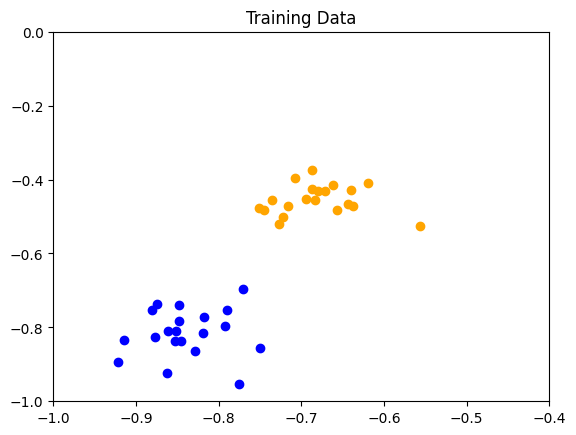

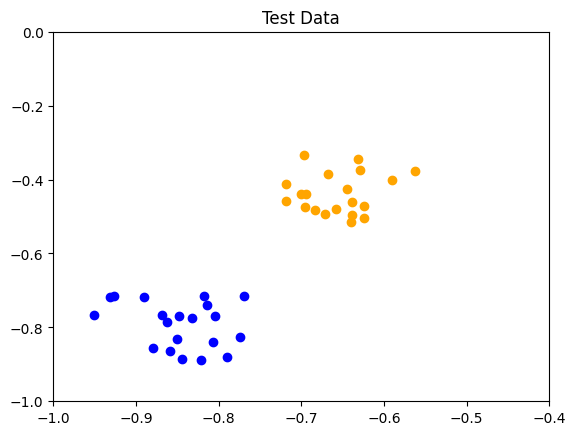

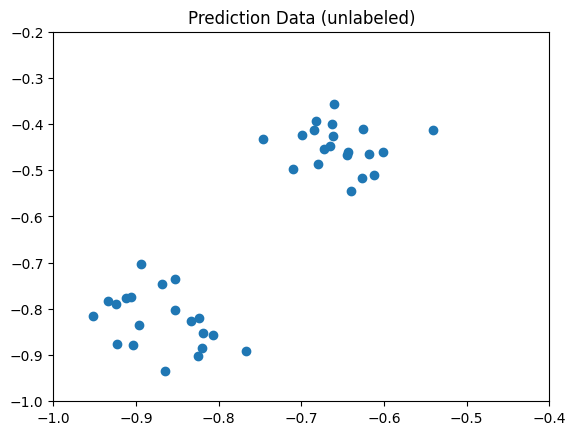

In [6]:
plot_range = (-1, -0.4)
colors = {0: "blue", 1: "orange"}
for i in range(TRAIN_DATA_1.shape[0]):
    plt.scatter(*TRAIN_DATA_1[i, :].T, c=colors[TRAIN_LABELS_1[i]])
plt.title("Training Data")
plt.xlim(plot_range)
plt.ylim((-1, 0))
plt.show()

for i in range(TRAIN_DATA_1.shape[0]):
    plt.scatter(*TEST_DATA_1[i, :].T, c=colors[TEST_LABELS_1[i]])
plt.title("Test Data")
plt.xlim(plot_range)
plt.ylim((-1, 0))
plt.show()

plt.scatter(*PREDICT_DATA_1.T)
plt.title("Prediction Data (unlabeled)")
plt.xlim((-1, -0.4))
plt.ylim((-1, -0.2))
plt.show()

Here the dark blue and orange dots correspond to the labels $0$ and $1$, and the prediction data is unlabelled.

### Defining the Feature Map
When constructing a QSVM model, we must supply the feature map, encoding the classical data into quantum states in Hilbert space (the feature space of the problem). Here, we choose to encode the data onto the surface of the Bloch sphere.


This can be defined in terms of the following transformation on the 2D data point $$\mathbf{x} = [x_0,x_1]^T\rightarrow R_Z(\pi x_1) R_X(\pi  x_0)|0\rangle = \cos(\pi x_0/2)|0\rangle + i e^{i \pi x_1}\sin(\pi x_0/2)|1\rangle~~,$$
where the circuit takes a single qubit per data point and the last equality is up to a global phase. 

We define a quantum function that generalizes the Bloch sphere mapping to an input vector of any dimension (also known as "dense angle encoding" in the field of quantum neural networks):
$$ RX(\pi x_{2i})RZ(\pi x_{2i+1})|i\rangle =  \cos(\pi x_{2i}/2)|0\rangle + i e^{i \pi x_{2i+1}}\sin(\pi x_{2i}/2)|1\rangle~~,
$$
where $x_i$ are the elements of the vector $\mathbf{x}$ and $d$ is the dimension of the vector. 

Each pair of entries in the vector is mapped to a Bloch sphere. If there is an odd size, we apply a single RX gate on an extra qubit. Since a single qubit stores the data of a single data point, for such a feature mapping the number of qubits required is $n=\lceil d/2 \rceil$.



The feature map is uploaded from the Classiq's open library.

### Constructing a Model

We begin by building Classiq's `QSVM` class, consisting of the QML model. The model is given a feature map, and possibly `ExecutionPreferences`. The feature map will be employed in the evaluation of the kernel in the training step.



In [7]:
# Build a quantum support vector machine model
bloch_num_qubits = int(np.ceil(np.log2(TRAIN_DATA_1.shape[1])))
qsvm_model = QSVM(feature_map=inplace_encode_on_bloch, num_qubits=bloch_num_qubits)

### Viewing the Generated Quantum Circuit
Before training, the quantum circuit used for kernel evaluation is accessible via `get_qprog`.

In [8]:
qprog_bloch = qsvm_model.get_qprog(data_dim=TRAIN_DATA_1.shape[1])
show(qprog_bloch)

Quantum program link: https://platform.classiq.io/circuit/3EEHzpInwJWGPXz9Nlequ7tatL1


### Executing QSVM
The execution involves the following steps:
1. Training
2. Testing the training process, and outputting a test score.
3. Predicting, by taking unlabeled data and returning its predicted labels. This may be applied multiple times on different datasets.

These steps are performed utilizing the `train`, `test` and `predict`  methods of the `QSVM` class.
In the training stage, the quantum kernel is constructed element by element, by repeated execution of quantum circuits. The execution employs Classiq's `sample_batch` to evaluate the overlap between the states encoding the two data points of each pair.
 The kernel matrix is then fed into scikit-learn's `SVC` (Support Vector Classifier) function to optimize the quadratic program (the dual optimization problem). The knowledge of the optimized coefficients enables the model to predict the classification of a new data point, utilizing Eq. (1).

In [9]:
# Train the model
qsvm_model.train(TRAIN_DATA_1, TRAIN_LABELS_1)

In [10]:
# Check the test score
test_score, test_predicted_labels = qsvm_model.test(TEST_DATA_1, TEST_LABELS_1)

# Predict labels
predicted_labels = qsvm_model.predict(PREDICT_DATA_1)

### Results

We can view the classification accuracy through `test_score`, moreover, since this data was previously generated, we also know the real labels and can print them for comparison.

In [11]:
# Printing tests result
print(f"Testing success ratio: {test_score}")
print()
# Printing predictions
print("Prediction from datapoints set:")
print(f"  ground truth: {predict_real_labels}")
print(f"  prediction:   {predicted_labels}")
print(
    f"  success rate: {100 * np.count_nonzero(predicted_labels == predict_real_labels) / len(predicted_labels)}%"
)

Testing success ratio: 1.0

Prediction from datapoints set:
  ground truth: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1]
  prediction:   [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1]
  success rate: 100.0%


We can even visualize the predicted results:

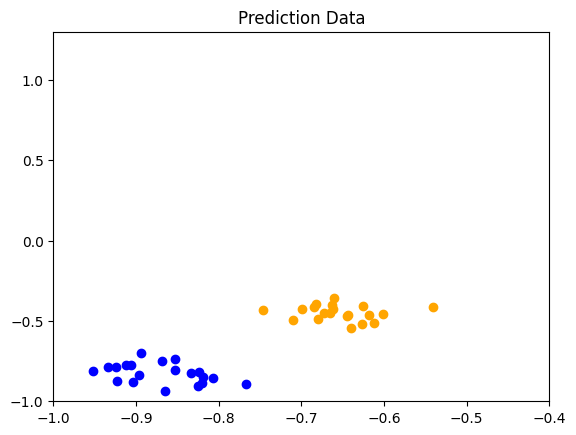

In [12]:
plt.figure()
for i in range(PREDICT_DATA_1.shape[0]):
    plt.scatter(*PREDICT_DATA_1[i, :].T, c=colors[predicted_labels[i]])
plt.title("Prediction Data")
plt.xlim(plot_range)
plt.ylim((-1, 1 + 0.3))
plt.show()

## Example 2: Pauli and Bloch Sphere Feature Map on a Complex Data Set

We begin by generating the dataset for this example.

In [13]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

We use the Iris dataset, classifying *versicolor* vs *virginica* using the two petal features (petal length and petal width). This binary task is non-trivial since the two classes partially overlap in the original feature space. The data is scaled to $[0, 2\pi]$ to match the range expected by the Pauli ZZ feature map.

In [14]:
# Load Iris dataset - classify versicolor vs virginica using petal features
iris = load_iris()
mask = iris.target != 0  # exclude setosa
X = iris.data[mask, 2:]  # petal length and width (columns 2 and 3)
y = iris.target[mask] - 1  # remap labels to {0, 1}

FEATURE_SIZE = X.shape[1]  # = 2

# Scale to [0, 2π] to match the range expected by the Pauli ZZ feature map
std_scaler = StandardScaler().fit(X)
X_std = std_scaler.transform(X)
mm_scaler = MinMaxScaler(feature_range=(0, 2 * np.pi)).fit(X_std)
X_scaled = mm_scaler.transform(X_std)

Split into train, test, and prediction sets.

In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
X_test, X_predict, y_test, y_predict = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

TRAIN_DATA_2, TRAIN_LABELS_2 = X_train, y_train
TEST_DATA_2, TEST_LABELS_2 = X_test, y_test
PREDICT_DATA_2 = X_predict
predict_real_labels_2 = y_predict

The data can be visualized by a color coded plot

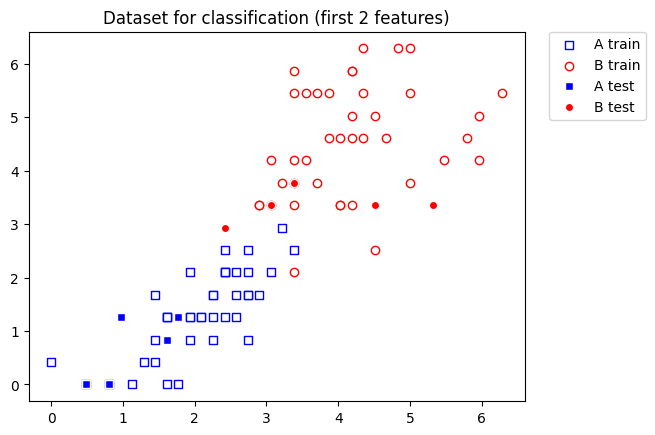

In [16]:
import matplotlib.pyplot as plt

plt.scatter(
    TRAIN_DATA_2[TRAIN_LABELS_2 == 0, 0],
    TRAIN_DATA_2[TRAIN_LABELS_2 == 0, 1],
    marker="s",
    facecolors="w",
    edgecolors="b",
    label="A train",
)
plt.scatter(
    TRAIN_DATA_2[TRAIN_LABELS_2 == 1, 0],
    TRAIN_DATA_2[TRAIN_LABELS_2 == 1, 1],
    marker="o",
    facecolors="w",
    edgecolors="r",
    label="B train",
)
plt.scatter(
    TEST_DATA_2[TEST_LABELS_2 == 0, 0],
    TEST_DATA_2[TEST_LABELS_2 == 0, 1],
    marker="s",
    facecolors="b",
    edgecolors="w",
    label="A test",
)
plt.scatter(
    TEST_DATA_2[TEST_LABELS_2 == 1, 0],
    TEST_DATA_2[TEST_LABELS_2 == 1, 1],
    marker="o",
    facecolors="r",
    edgecolors="w",
    label="B test",
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
plt.title("Dataset for classification (first 2 features)")
plt.show()

### Pauli Feature Map

We build a Pauli feature map. This feature map is of size $N$ qubits for data $\mathbf{x}$ of size $N$, and it corresponds to the following unitary:
$$
U = \exp\left(\sum f^{(1)}_k(\mathbf{x})H^{(1)}_k + \sum f^{(2)}_k(\mathbf{x})H^{(2)}_k+\dots \right) H^{\otimes n}~~,
$$
where $H^{\otimes n}$ designates the Hadamard transform, and $H^{(i)}$ is a Hamiltonian acting on $i$ qubits according to some connectivity map, and $f^{(i)}$ is some classical function, typically taken as the polynomial of degree $i$. For example, if our data is of size $3$ and we assume circular connectivity, taking Hamiltonians depending only on $Z$, the Hamiltonian reads as
$$
\sum f^{(1)}_k(\mathbf{x})H^{(1)}_k = \alpha(x_0+\beta)ZII+\alpha(x_1+\beta)IZI+\alpha(x_2+\beta)IIZ,
$$
$$
\sum f^{(2)}_k(\mathbf{x})H^{(2)}_k = \gamma^2(x_0+\zeta)(x_1+\zeta)ZZI+\gamma^2(x_1+\zeta)(x_2+\zeta)IZZ + \gamma^2(x_0+\zeta)(x_3+\zeta)ZIZ~~,
$$
where $(\alpha,\beta)$ and $(\gamma,\zeta)$ define some affine transformation on the data and correspond to the functions $f^{(1,2)}$.

We start by defining classical functions for creating a connectivity map for the Hamiltonians and for generating the full Hamiltonian:

### Model Construction

We first define the hyperparameters of the Pauli feature map and construct an appropriate wrapper feature map, utilizing `pauli_feature_map`.

In [17]:
# Define the parameters for the Pauli feature map
N_DIM = FEATURE_SIZE
PAULIS = [[Pauli.Z], [Pauli.Z, Pauli.Z]]
CONNECTIVITY = 2  # ConnectivityType.FULL — all qubit pairs interact
AFFINES = [[1, 0], [1, np.pi]]
REPS = 2

# Build the wrapper function for the Pauli feature map
feature_map = lambda data, qba: pauli_feature_map(
    data, PAULIS, AFFINES, CONNECTIVITY, REPS, qba
)

Next, the model is constructed

In [18]:
pauli_num_qubits = N_DIM
# Build a quantum support vector machine model
qsvm_model_pauli = QSVM(feature_map=feature_map, num_qubits=pauli_num_qubits)

### Viewing the Generated Quantum Circuit
Before training, the quantum circuit used for kernel evaluation is accessible via `get_qprog`.

In [19]:
qprog_pauli = qsvm_model_pauli.get_qprog(data_dim=N_DIM)
show(qprog_pauli)

Quantum program link: https://platform.classiq.io/circuit/3EEI4f9X9d9UPMNnqyXnpDHd30k


### Train, Test and Prediction of the Pauli Model

In [20]:
# Train the model
qsvm_model_pauli.train(TRAIN_DATA_2, TRAIN_LABELS_2)

# Check the test score
test_score_pauli, test_predicted_labels_pauli = qsvm_model_pauli.test(
    TEST_DATA_2, TEST_LABELS_2
)

# Predict labels
predicted_labels_pauli = qsvm_model_pauli.predict(PREDICT_DATA_2)

### Prediction Utilizing the Bloch Feature Map

We compare the Pauli feature map to the Bloch feature map results. For that end, we construct a new model, using the `inplace_encode_on_bloch`, as in the first example above.

In [21]:
bloch_num_qubits_2 = int(np.ceil(np.log2(N_DIM)))
# Build a quantum support vector machine model
qsvm_model_bloch = QSVM(
    feature_map=inplace_encode_on_bloch, num_qubits=bloch_num_qubits_2
)

qprog_bloch_2 = qsvm_model_bloch.get_qprog(data_dim=N_DIM)
show(qprog_bloch_2)

Quantum program link: https://platform.classiq.io/circuit/3EEICE0EPmJFCHR7WHBqYyRht2m


In [22]:
# Train the model
qsvm_model_bloch.train(TRAIN_DATA_2, TRAIN_LABELS_2)

# Check the test score
test_score_bloch, test_predicted_labels_bloch = qsvm_model_bloch.test(
    TEST_DATA_2, TEST_LABELS_2
)

# Predict labels
predicted_labels_bloch = qsvm_model_bloch.predict(PREDICT_DATA_2)

### Results

The Pauli feature map accurately classifies the test and prediction data sets.

In [23]:
# Printing tests result
print(f"Testing success ratio for the Pauli feature map: {test_score_pauli}")
print()
# Printing predictions
print("Prediction from datapoints set:")
print(f"ground truth: {predict_real_labels_2}")
print(f"prediction:   {predicted_labels_pauli}")
print(
    f"success rate: {100 * np.count_nonzero(predicted_labels_pauli == predict_real_labels_2) / len(predicted_labels_pauli)}%"
)

Testing success ratio for the Pauli feature map: 1.0

Prediction from datapoints set:
ground truth: [0 1 1 0 1 0 0 0 1 1]
prediction:   [0 1 1 1 0 1 0 0 1 1]
success rate: 70.0%


In comparison, the Bloch sphere feature map achieves lower accuracy in the classification task.

In [24]:
# Printing tests result
print(f"Testing success ratio for the Bloch sphere feature map: {test_score_bloch}")
print()
# Printing predictions
print("Prediction from datapoints set:")
print(f"ground truth: {predict_real_labels_2}")
print(f"prediction:   {predicted_labels_bloch}")
print(
    f"success rate: {100 * np.count_nonzero(predicted_labels_bloch == predict_real_labels_2) / len(predicted_labels_bloch)}%"
)

Testing success ratio for the Bloch sphere feature map: 0.8

Prediction from datapoints set:
ground truth: [0 1 1 0 1 0 0 0 1 1]
prediction:   [0 0 1 1 0 0 0 0 0 1]
success rate: 60.0%


### Classical Baseline: RBF Kernel SVM

To put the quantum results in context, we compare against a classical SVM with a radial basis function (RBF) kernel — the standard non-linear classical baseline. The RBF kernel measures Euclidean similarity between data points and can be expressed as an infinite Taylor series of polynomial kernels, making it a strong and flexible classifier.

In [25]:
from sklearn.svm import SVC

# Train classical SVM with RBF kernel
svc_rbf = SVC(kernel="rbf", random_state=42)
svc_rbf.fit(TRAIN_DATA_2, TRAIN_LABELS_2)

test_score_rbf = svc_rbf.score(TEST_DATA_2, TEST_LABELS_2)
predicted_labels_rbf = svc_rbf.predict(PREDICT_DATA_2)
success_rate_rbf = (
    100
    * np.count_nonzero(predicted_labels_rbf == predict_real_labels_2)
    / len(predict_real_labels_2)
)

print(f"Testing success ratio for the classical RBF kernel SVM: {test_score_rbf}")
print()
print("Prediction from datapoints set:")
print(f"ground truth: {predict_real_labels_2}")
print(f"prediction:   {predicted_labels_rbf}")
print(f"success rate: {success_rate_rbf}%")

Testing success ratio for the classical RBF kernel SVM: 0.9

Prediction from datapoints set:
ground truth: [0 1 1 0 1 0 0 0 1 1]
prediction:   [0 1 0 0 1 1 0 0 1 1]
success rate: 80.0%


## Summary and Discussion

The notebook demonstrated the application of the Quantum Support Vector Machine (QSVM) algorithm through two examples, each paired with a quantum feature map suited to the data structure.

In the first example, a linearly separable dataset was classified using the Bloch sphere feature map. The single-qubit Bloch encoding is efficient — it encodes two features into one qubit — and fully sufficient for this task, achieving perfect classification accuracy.

In the second example, the Iris *versicolor* vs *virginica* task was classified using both quantum and classical methods:

- **Pauli ZZ feature map (quantum):** captures pairwise cross-feature interactions via ZZ Hamiltonian terms, achieving the highest quantum accuracy.
- **Bloch sphere feature map (quantum):** treats features independently per qubit, resulting in lower accuracy on this partially-overlapping dataset.
- **Classical RBF kernel SVM:** the standard non-linear classical baseline, included for comparison.

The results illustrate a central principle in QSVM design: the quantum feature map should be matched to the structure of the data. Simple encodings are efficient and sufficient for simple boundaries; more expressive encodings are necessary when the decision boundary depends on feature interactions. The classical RBF baseline contextualizes the quantum results, showing where quantum feature maps stand relative to a well-established classical method on this dataset.

## Reference

<a id='learning'>[1]</a> [Havlíček, V., Córcoles, A. D., Temme, K., Harrow, A. W., Kandala, A., Chow, J. M., & Gambetta, J. M. (2019). Supervised learning with quantum-enhanced feature spaces. Nature, 567(7747), 209-212.](https://arxiv.org/abs/1804.11326)

<a id='speedup'>[2]</a> [Liu, Y., Arunachalam, S., & Temme, K. (2021). A rigorous and robust quantum speed-up in supervised machine learning. Nature Physics, 17(9), 1013-1017.](https://arxiv.org/abs/2010.02174)

<a id='KKT'>[3]</a> [Karush–Kuhn–Tucker conditions](https://en.wikipedia.org/wiki/Karush%E2%80%93Kuhn%E2%80%93Tucker_conditions)